# Step 4 — Project the 11 ST clusters onto METABRIC

Visualises the result of transferring the TCGA-derived 11 ST clusters onto the METABRIC
breast cancer cohort (n=141). The transfer itself is run upstream in R using Seurat's
`FindTransferAnchors` + `TransferData` (see
`spatial_clusters/3_transfer_check_param_METABRIC.r`); this notebook just loads the
per-patient × per-cluster composition matrix and renders the heatmap (Figure S7A).

**Inputs (committed under `clustering/data/`)**
- `metabric_cluster_props.csv` — 141 patients × 11 cluster proportions + assigned SpatioType.

The proportions are computed from the per-domain transfer output `best_clust.RDS`
(1099 SpaGCN domains across 158 METABRIC slides, of which 141 have SpatioType labels):
for each patient, `proportion_of_spots` was summed across domains within each Cluster.

**Output**
- The Figure-S7A-style heatmap of cluster composition, with columns split by SpatioType.

## Setup

In [1]:
import sys
sys.path.append("../lib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

from clustering_helpers import (
    SPATIOTYPE_PALETTE, HEATMAP_ROW_ORDER, SPATIOTYPE_LEVELS,
)

import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

/home/shulmaned/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Load the projected cluster proportions

In [2]:
df = pd.read_csv("../data/metabric_cluster_props.csv", index_col=0)
cluster_cols = [f"Cluster_{i}" for i in range(1, 12)]
df.shape, df["SpatioType"].value_counts().to_dict()

((141, 12),
 {'Immune-Modulated': 122, 'Immune-Inactive': 10, 'Proliferative': 9})

## Heatmap of cluster proportions

Rows = the 11 ST clusters in the same order used in the TCGA heatmap (notebook 03).
Columns = METABRIC patients, grouped by SpatioType and ordered within each block by
the per-row Euclidean distance. Colours: viridis for the proportions, JAMA palette for
the SpatioType annotation bar.

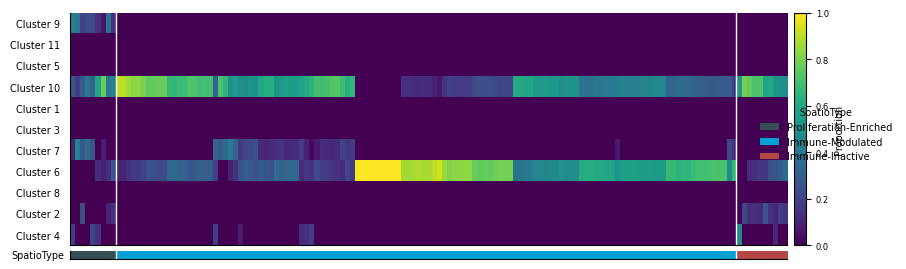

In [3]:
# Rename Cluster_<n> to "Cluster <n>" to match HEATMAP_ROW_ORDER
df_h = df.rename(columns={f"Cluster_{i}": f"Cluster {i}" for i in range(1, 12)})

main_spatiotypes = ["Proliferation-Enriched", "Immune-Modulated", "Immune-Inactive"]
# The METABRIC dataset uses the short label "Proliferative" not "Proliferation-Enriched"
# (the TransferData labels were assigned by the upstream R pipeline).
df_h["SpatioType"] = df_h["SpatioType"].replace({"Proliferative": "Proliferation-Enriched"})

# Reorder patients: first by SpatioType (in paper order), then by Ward sub-order inside each block.
from scipy.cluster.hierarchy import linkage, leaves_list

ordered_idx = []
for st in main_spatiotypes:
    block = df_h.index[df_h["SpatioType"] == st]
    if len(block) > 1:
        sub_mat = df_h.loc[block, HEATMAP_ROW_ORDER].values
        sub_Z = linkage(sub_mat, method="ward")
        block = block[leaves_list(sub_Z)]
    ordered_idx.extend(block)

heat = df_h.loc[ordered_idx, HEATMAP_ROW_ORDER].T.values          # 11 × 141
col_st = df_h.loc[ordered_idx, "SpatioType"].values

# Block boundaries
boundaries = []
prev = col_st[0]
for i, st in enumerate(col_st):
    if st != prev:
        boundaries.append(i); prev = st

fig = plt.figure(figsize=(9.5, 3.2))
gs = gridspec.GridSpec(2, 2, figure=fig,
                       width_ratios=[60, 1], height_ratios=[30, 1],
                       hspace=0.05, wspace=0.02)

ax_h = fig.add_subplot(gs[0, 0])
im = ax_h.imshow(heat, aspect="auto", cmap="viridis", interpolation="nearest", vmin=0, vmax=1)
for b in boundaries:
    ax_h.axvline(b - 0.5, color="white", linewidth=1.0)
ax_h.set_yticks(range(len(HEATMAP_ROW_ORDER)))
ax_h.set_yticklabels(HEATMAP_ROW_ORDER, fontsize=7)
ax_h.set_xticks([])
ax_h.tick_params(left=False)

ax_cb = fig.add_subplot(gs[0, 1])
plt.colorbar(im, cax=ax_cb).set_label("Proportion", fontsize=7)
ax_cb.tick_params(labelsize=6)

ax_a = fig.add_subplot(gs[1, 0], sharex=ax_h)
rgb = np.array([list(mcolors.to_rgb(SPATIOTYPE_PALETTE[s])) for s in col_st])[None, :, :]
ax_a.imshow(rgb, aspect="auto", interpolation="nearest")
ax_a.set_xticks([]); ax_a.set_yticks([])
ax_a.set_ylabel("SpatioType", rotation=0, ha="right", va="center", fontsize=7)
for b in boundaries:
    ax_a.axvline(b - 0.5, color="white", linewidth=1.0)

handles = [mpatches.Patch(facecolor=SPATIOTYPE_PALETTE[s], label=s) for s in main_spatiotypes]
fig.legend(handles=handles, loc="center right", bbox_to_anchor=(1.0, 0.5),
           fontsize=7, frameon=False, title="SpatioType", title_fontsize=7)
plt.show()